In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = "../data/training/image_2"
MASK_DIR = "../data/training/gt_image_2"

def get_mask_name(img_name):
    stem = img_name.replace(".png", "")
    prefix, idx = stem.split("_", 1)
    return f"{prefix}_road_{idx}.png"

def load_image_and_gt(img_name, image_dir=IMAGE_DIR, mask_dir=MASK_DIR):
    img_path = os.path.join(image_dir, img_name)
    mask_name = get_mask_name(img_name)
    mask_path = os.path.join(mask_dir, mask_name)

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    mask_bgr = cv2.imread(mask_path)
    if mask_bgr is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)

    flat = mask_rgb.reshape(-1, 3)
    colors, counts = np.unique(flat, axis=0, return_counts=True)
    background_color = colors[np.argmax(counts)]

    gt = np.any(mask_rgb != background_color, axis=-1)

    return img, gt, mask_rgb

def classical_baseline(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    kernel = np.ones((5, 5), np.uint8)
    pred = cv2.dilate(edges, kernel, iterations=2)
    pred = cv2.morphologyEx(pred, cv2.MORPH_CLOSE, kernel)

    return pred > 0

def dice_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    return 2 * intersection / (pred.sum() + gt.sum() + 1e-8)

def add_gaussian_noise(img, std=25):
    noise = np.random.normal(0, std, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_blur(img):
    return cv2.GaussianBlur(img, (9, 9), 0)

def add_low_light(img):
    return (img * 0.5).astype(np.uint8)

def evaluate_with_degradation(image_dir=IMAGE_DIR):
    img_names = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])

    results = {
        "clean": [],
        "noise": [],
        "blur": [],
        "low_light": []
    }

    for img_name in img_names:
        img, gt, _ = load_image_and_gt(img_name)

        versions = {
            "clean": img,
            "noise": add_gaussian_noise(img),
            "blur": add_blur(img),
            "low_light": add_low_light(img)
        }

        for k, v in versions.items():
            pred = classical_baseline(v)
            d = dice_score(pred, gt)
            results[k].append(d)

    mean_results = {k: np.mean(v) for k, v in results.items()}
    return mean_results

In [3]:
results = evaluate_with_degradation()
results

{'clean': np.float64(0.18825283647227428),
 'noise': np.float64(0.3558019168475669),
 'blur': np.float64(0.14629333877931),
 'low_light': np.float64(0.15403156743711424)}

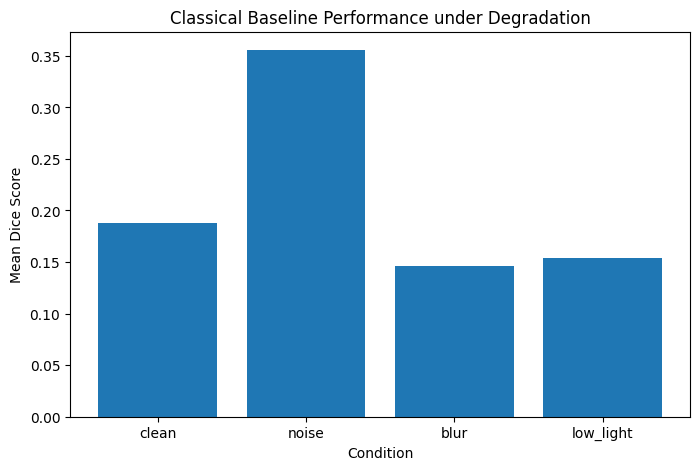

In [4]:
import pandas as pd

results_df = pd.DataFrame({
    "Condition": list(results.keys()),
    "Classical Dice": list(results.values())
})

results_df
plt.figure(figsize=(8, 5))
plt.bar(results_df["Condition"], results_df["Classical Dice"])
plt.title("Classical Baseline Performance under Degradation")
plt.ylabel("Mean Dice Score")
plt.xlabel("Condition")
plt.show()

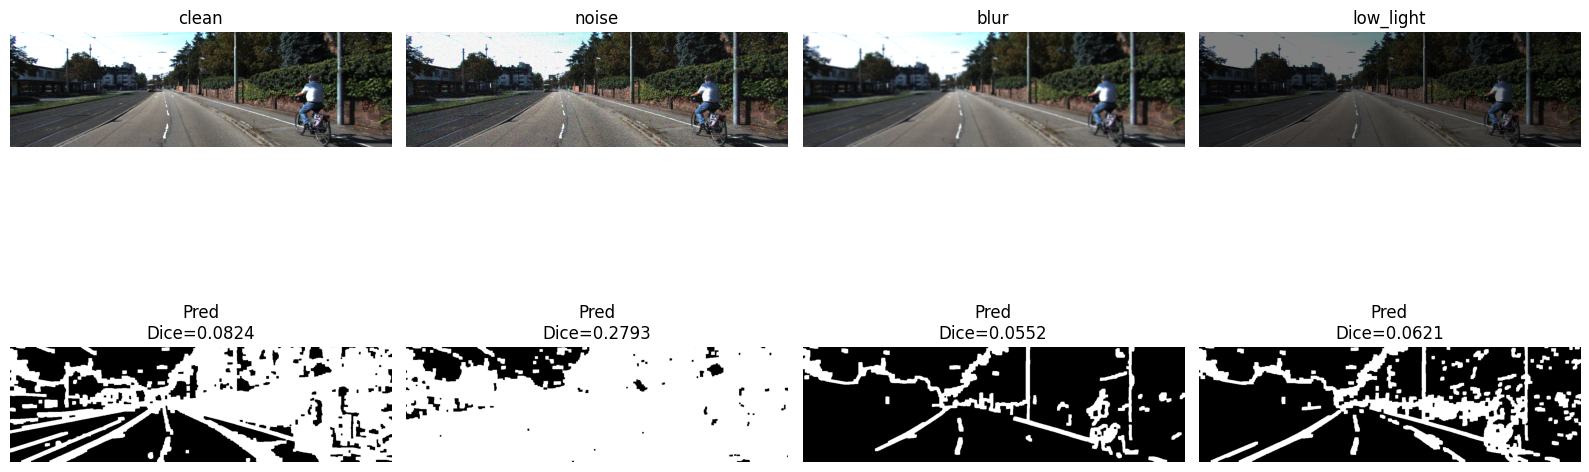

In [6]:
sample_name = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith(".png")])[0]
img, gt, _ = load_image_and_gt(sample_name)

versions = {
    "clean": img,
    "noise": add_gaussian_noise(img),
    "blur": add_blur(img),
    "low_light": add_low_light(img)
}

plt.figure(figsize=(16, 8))

for i, (name, version) in enumerate(versions.items()):
    pred = classical_baseline(version)
    d = dice_score(pred, gt)

    plt.subplot(2, 4, i + 1)
    plt.imshow(version)
    plt.title(f"{name}")
    plt.axis("off")

    plt.subplot(2, 4, i + 5)
    plt.imshow(pred, cmap="gray")
    plt.title(f"Pred\nDice={d:.4f}")
    plt.axis("off")

plt.tight_layout()

plt.savefig("../results/failure_cases.png")